In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Seed
random.seed(42)
np.random.seed(42)

In [3]:
# Global variables
CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
DATA_PATH = os.path.join(CURRENT_DIR, 'data', 'tabular', 'real', 'rt_iot2022')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints', 'tabular', 'real', 'rt_iot2022')
OUT_PATH = os.path.join(CURRENT_DIR, 'out', 'tabular', 'real', 'rt_iot2022')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

# Show info on the terminal about how the execution is going.
VERBOSE = True
# Even if there is a checkpoint, the model is retrained.
FORCE_TRAINING = True
# Name of this experiment that will appear in the result files.
SUBFIX_NAME = 'gradient'

In [11]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
rt_iot2022 = fetch_ucirepo(id=942)

# data (as pandas dataframes)
df_data = rt_iot2022.data.features
y = rt_iot2022.data.targets

In [12]:
df_data.describe()['active.avg'].T

count    1.231170e+05
mean     1.481354e+05
std      1.613007e+06
min      0.000000e+00
25%      9.536740e-01
50%      4.053116e+00
75%      5.006790e+00
max      4.374931e+08
Name: active.avg, dtype: float64

In [13]:
df_data.nunique()

id.orig_p               65478
id.resp_p                1809
proto                       3
service                    10
flow_duration           16381
                        ...  
idle.avg                 5670
idle.std                 1001
fwd_init_window_size       20
bwd_init_window_size       56
fwd_last_window_size      109
Length: 83, dtype: int64

In [14]:
df_data = df_data.drop(columns=df_data.columns[df_data.nunique()<2])

Hay entradas de X con distintas salida Y ya que existen menos duplicados teniendo en cuenta la columna target que sin ella.

In [15]:
total = pd.concat([df_data, y], axis=1)
total.duplicated().sum(), df_data.duplicated().sum(), total.isna().sum().sum()

(5195, 5202, 0)

In [16]:
df_data = df_data.drop_duplicates()

In [17]:
df_data.shape, df_data.duplicated().sum()

((117915, 82), 0)

In [18]:
columnas_categoricas = df_data.select_dtypes(include=['object', 'category']).columns.tolist()
columnas_categoricas

['proto', 'service']

In [19]:
df_data = pd.get_dummies(df_data, columns=columnas_categoricas, drop_first=True)
dummy_columns = df_data.columns[df_data.columns.str.startswith(tuple(columnas_categoricas))]
df_data[dummy_columns] = df_data[dummy_columns].astype(int)

In [20]:
df_data.shape

(117915, 91)

<Axes: >

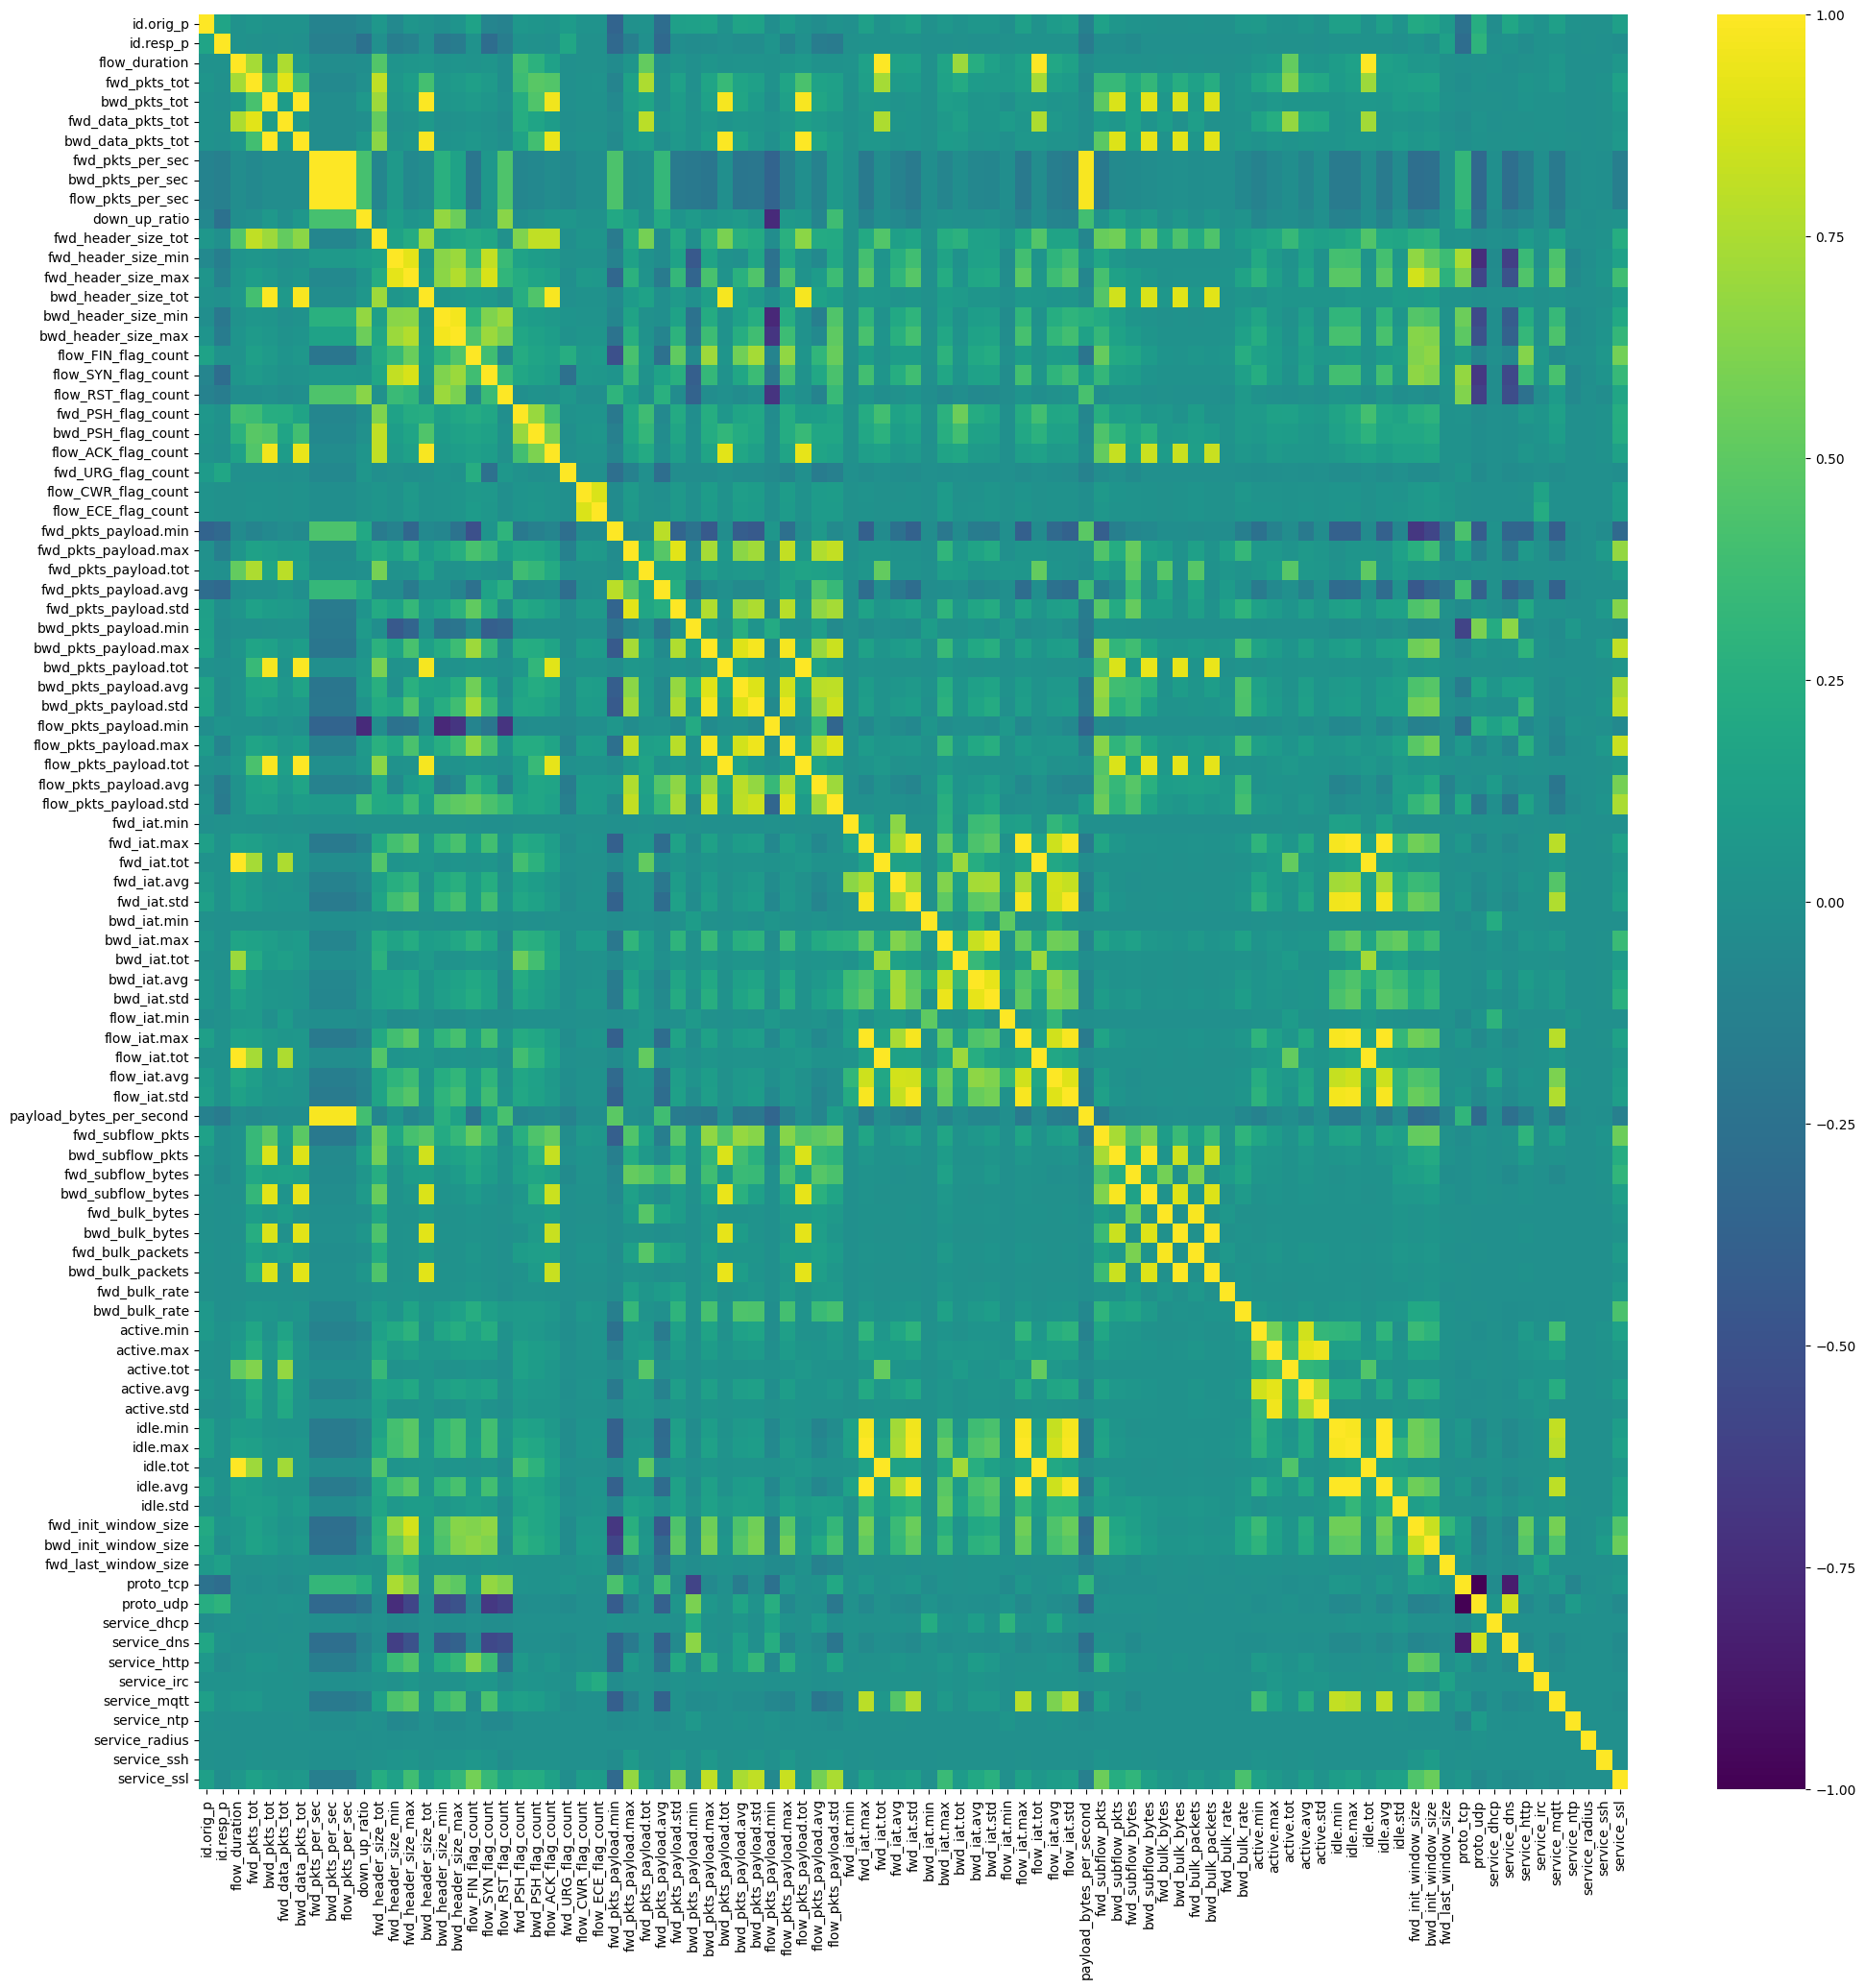

In [21]:
corr = df_data.corr()
plt.figure(figsize=(24, 24))
sns.heatmap(corr, cmap="viridis", vmax=1, vmin=-1)

In [22]:
df_data['y'] = df_data['active.avg']

In [24]:
drop_columns = df_data.columns.str.startswith(('active', 'idle'))
df_data = df_data.drop(columns=df_data.columns[drop_columns])

In [25]:
df_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id.orig_p,117915.0,34950.985176,1.896501e+04,0.0,18355.500000,37536.000000,51036.000000,6.553500e+04
id.resp_p,117915.0,1050.690769,5.364635e+03,0.0,21.000000,21.000000,21.000000,6.538900e+04
flow_duration,117915.0,3.808700,1.270680e+02,0.0,0.000001,0.000004,0.000005,2.172834e+04
fwd_pkts_tot,117915.0,2.290294,2.211211e+01,0.0,1.000000,1.000000,1.000000,4.345000e+03
bwd_pkts_tot,117915.0,1.942883,3.372867e+01,0.0,1.000000,1.000000,1.000000,1.011200e+04
...,...,...,...,...,...,...,...,...
service_ntp,117915.0,0.000975,3.121435e-02,0.0,0.000000,0.000000,0.000000,1.000000e+00
service_radius,117915.0,0.000017,4.118401e-03,0.0,0.000000,0.000000,0.000000,1.000000e+00
service_ssh,117915.0,0.000237,1.540795e-02,0.0,0.000000,0.000000,0.000000,1.000000e+00
service_ssl,117915.0,0.022525,1.483830e-01,0.0,0.000000,0.000000,0.000000,1.000000e+00


In [26]:
df_data.to_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)

In [5]:
df_data = pd.read_parquet(
    os.path.join(
        DATA_PATH,
        'clean.parquet'
    )
)
df_data.shape

(117915, 82)